>In this notebook, the concepts of text mining and natural language processing are explained. The reader is taken by the hand and it is explained step by step how it works.

![https://3nions.com/wp-content/uploads/2020/01/comp_1.gif](https://3nions.com/wp-content/uploads/2020/01/comp_1.gif)
Twitter has become an important communication channel in times of emergency.
The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).

But, it’s not always clear whether a person’s words are actually announcing a disaster. 
<p style="font-size : 12px"><em>extract from the competition description</em></p>
<p style="font-size : 12px"><em>gif from: https://3nions.com/wp-content/uploads/2020/01/comp_1.gif</em></p>


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<h3 data-toggle="list"  role="tab" aria-controls="home"><p style="font-size : 25px"><font color="grey">Overview:</font></p></h3>

1. [<font color="grey">Data Preparation<font/>](#1)      
2. [<font color="grey">Wordcloud<font/>](#2)
3. [<font color="grey">Deep Learning<font/>](#3)<br>
    - 3.1 [<font color="grey">Tokenizer<font/>](#3.1)
    - 3.2 [<font color="grey">Auto Encoder<font/>](#3.2)
    - 3.3 [<font color="grey">Deep Learning Architecture<font/>](#3.3)
    - 3.4 [<font color="grey">Cross Validation<font/>](#3.4)
    - 3.5 [<font color="grey">Final Model<font/>](#3.5)  
4. [<font color="grey">Submission<font/>](#4)

In [1]:
options(warn=-1)
set.seed(111)

library(data.table)
library(tm)
library(ggplot2)
library(ggwordcloud)
library(keras)
library(tensorflow)
library(plotly)
library(htmlwidgets)
library(IRdisplay)
library(hunspell)
library(gridExtra)
library(DT)

install.packages("qdap")
library(qdap)

dir.create(file.path("charts/"), showWarnings = FALSE)

Loading required package: NLP


Attaching package: ‘NLP’


The following object is masked from ‘package:httr’:

    content



Attaching package: ‘ggplot2’


The following object is masked from ‘package:NLP’:

    annotate


The following object is masked from ‘package:data.table’:

    :=



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout


The following object is masked from ‘package:httr’:

    config


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘openNLPdata’, ‘rJava’, ‘gender’, ‘openNLP’, ‘venneuler’


Loading required package: qdapDictionaries

Loading required package: qdapRegex


Attaching package: ‘qdapRegex’


The following object is masked from ‘package:ggplot2’:

    %+%


Loading required package: qdapTools


Attachi

<font size="+2" color="grey"><b>1. Data Preparation </b></font><br><a id="1"></a>

The tm-package is a text mining package. With keras it is the most important one for the following explanations.

For text mining, first step is to read the text files. It depends on the formats whether it is .pdf, .csv, .docx or another kind of format. 

In [2]:
tm::getSources

function () 
c("DataframeSource", "DirSource", "URISource", "VectorSource", 
    "XMLSource", "ZipSource")
<bytecode: 0x5616a506f8d0>
<environment: namespace:tm>

Reading the data:

In [3]:
TRAIN <- fread("../input/nlp-getting-started/train.csv", data.table = F)
TEST <- fread("../input/nlp-getting-started/test.csv", data.table = F)

In [4]:
unlist(strsplit(as.character(TRAIN$text[1]), split = " ")) %>%
hunspell_check()

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE
[13]  TRUE

Data dimensions:

In [5]:
dim(TRAIN); dim(TEST)

[1] 7613    5

[1] 3263    4

Let´s take a look at the data:

In [6]:
dtW <- DT::datatable(TRAIN)

path <-"charts/dtW.html"
saveWidget(dtW, file.path(normalizePath(dirname(path)),basename(path)))
IRdisplay::display_html('<iframe src="charts/dtW.html" align="center" width="100%" height="500" frameBorder="0"></iframe>')

After reading the data, first step is to create a text corpus. A corpus gives the text data a controllable structure. This makes it possible to select specific text components. In this case, the tweeds. (*If you read a -pdf for example, you might get the pages instead*)

In [7]:
corpTRAIN <- Corpus(VectorSource(TRAIN$text))
corpTEST <- Corpus(VectorSource(TEST$text))

In [8]:
corpTRAIN

<<SimpleCorpus>>
Metadata:  corpus specific: 1, document level (indexed): 0
Content:  documents: 7613



We have one corpus containing 7613 documents. The corpus allows us to perform all possible cleanups.

* tolower is used to compare words from the start of a sentence with other words.
* removement of emojis 🤬
* In the English language, cotractions are often used. These are converted back to the original form by appropriate vectors.
* removement of punctations and numbers to obtain a clean text.
* dropping stopwords. Stopwords are words with no specific meaning like "a", "the", or "by".
* stemming is an alorithm (in this case Porter) to find the word stem. For example, the stem of the words "paint", "painted", "painting" is the same.
* dropping URLs.
* After all those cleanups the text might have many whitespaces besides. So, a stripping of whitespaces reduces multiple whitespaces to one between each word.

We define a function to do all the mentioned steps:


In [9]:
emojis <- c("\U0001F600-\U0001F64F", "\U0001F300-\U0001F5FF", "\U0001F680-\U0001F6FF", "\U0001F1E0-\U0001F1FF", "\U00002702-\U000027B0", "\U000024C2-\U0001F251")

Contractions are hidden. Click on "code" to get insight.

Contractions are from [here](https://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python)

In [10]:
contractions_1 = c( 
"ain't",
"aren't",
"can't",
"can't've",
"'cause",
"could've",
"couldn't",
"couldn't've",
"didn't",
"doesn't",
"don't",
"hadn't",
"hadn't've",
"hasn't",
"haven't",
"he'd",
"he'd've",
"he'll",
"he'll've",
"he's",
"how'd",
"how'd'y",
"how'll",
"how's",
"I'd",
"I'd've",
"I'll",
"I'll've",
"I'm",
"I've",
"isn't",
"it'd",
"it'd've",
"it'll",
"it'll've",
"it's",
"let's",
"ma'am",
"mayn't",
"might've",
"mightn't",
"mightn't've",
"must've",
"mustn't",
"mustn't've",
"needn't",
"needn't've",
"o'clock",
"oughtn't",
"oughtn't've",
"shan't",
"sha'n't",
"shan't've",
"she'd",
"she'd've",
"she'll",
"she'll've",
"she's",
"should've",
"shouldn't",
"shouldn't've",
"so've",
"so's",
"that'd",
"that'd've",
"that's",
"there'd",
"there'd've",
"there's",
"they'd",
"they'd've",
"they'll",
"they'll've",
"they're",
"they've",
"to've",
"wasn't",
"we'd",
"we'd've",
"we'll",
"we'll've",
"we're",
"we've",
"weren't",
"what'll",
"what'll've",
"what're",
"what's",
"what've",
"when's",
"when've",
"where'd",
"where's",
"where've",
"who'll",
"who'll've",
"who's",
"who've",
"why's",
"why've",
"will've",
"won't",
"won't've",
"would've",
"wouldn't",
"wouldn't've",
"y'all",
"y'all'd",
"y'all'd've",
"y'all're",
"y'all've",
"you'd",
"you'd've",
"you'll",
"you'll've",
"you're",
"you've"
)

contractions_2 = c( 
"am not",
"are not",
"cannot",
"cannot have",
"because",
"could have",
"could not",
"could not have",
"did not",
"does not",
"do not",
"had not",
"had not have",
"has not",
"have not",
"he would",
"he would have",
"he will",
"he will have",
"he is",
"how did",
"how do you",
"how will",
"how is",
"I would",
"I would have",
"I will",
"I will have",
"I am",
"I have",
"is not",
"it would",
"it would have",
"it will",
"it will have",
"it is",
"let us",
"madam",
"may not",
"might have",
"might not",
"might not have",
"must have",
"must not",
"must not have",
"need not",
"need not have",
"of the clock",
"ought not",
"ought not have",
"shall not",
"shall not",
"shall not have",
"she would",
"she would have",
"she will",
"she will have",
"she is",
"should have",
"should not",
"should not have",
"so have",
"so is",
"that would",
"that would have",
"that is",
"there would",
"there would have",
"there is",
"they would",
"they would have",
"they will",
"they will have",
"they are",
"they have",
"to have",
"was not",
"we would",
"we would have",
"we will",
"we will have",
"we are",
"we have",
"were not",
"what will",
"what will have",
"what are",
"what is",
"what have",
"when is",
"when have",
"where did",
"where is",
"where have",
"who will",
"who will have",
"who is",
"who have",
"why is",
"why have",
"will have",
"will not",
"will not have",
"would have",
"would not",
"would not have",
"you all",
"you all would",
"you all would have",
"you all are",
"you all have",
"you would",
"you would have",
"you will",
"you will have",
"you are",
"you have"
)

contra <- data.frame(contractions_1, contractions_2)
colnames(contra) <- c("contraction", "expanded")

#data(contractions)

In [11]:
cleanUp <- function(CORPUS){
    CORPUS <- tm_map(CORPUS, content_transformer(tolower))
    CORPUS <- tm_map(CORPUS, content_transformer(function(x){mgsub(x, pattern = emojis, replacement = "")}))
    CORPUS <- tm_map(CORPUS, content_transformer(function(x){replace_contraction(x, contraction = contra)}))
    CORPUS <- tm_map(CORPUS, content_transformer(removePunctuation), ucp = F)
    CORPUS <- tm_map(CORPUS, content_transformer(removeNumbers))
    CORPUS <- tm_map(CORPUS, removeWords, stopwords("english"))
    CORPUS <- tm_map(CORPUS, stemDocument, language = "english")
    CORPUS <- tm_map(CORPUS, content_transformer(function(x){gsub("\\S*http+\\S*", "", x)}))
    CORPUS <- tm_map(CORPUS, stripWhitespace)
}

In [12]:
Example1 <- as.character(corpTRAIN[[16]])
Example2 <- as.character(corpTRAIN[[39]])

Application of the cleanUp function:

In [13]:
corpTRAIN <- cleanUp(corpTRAIN)
corpTEST <- cleanUp(corpTEST)

Let´s check the results (printing some tweets):

In [14]:
a = paste("Before: ", Example1, " After: ", as.character(corpTRAIN[[16]]), sep = "")
b = paste("Before: ", Example2, " After: ", as.character(corpTRAIN[[39]]), sep = "")
cat(a, b, sep = "\n\n")

Before: What's up man? After: What man

Before: Barbados #Bridgetown JAMAICA ÛÒ Two cars set ablaze: SANTA CRUZ ÛÓ Head of the St Elizabeth Police Superintende...  http://t.co/wDUEaj8Q4J After: Barbado bridgetown jamaica ûò two car set ablaz santa cruz ûó head st elizabeth polic superintend 


For explanation purpose, it makes sense to create a dataset containing the number of each word in each document. This kind of dataset is called a term document matrix:

In [15]:
tdmTR <- TermDocumentMatrix(corpTRAIN)

The term document matrix looks like this:

In [16]:
inspect(tdmTR[1:10,]) 

<<TermDocumentMatrix (terms: 10, documents: 7613)>>
Non-/sparse entries: 592/75538
Sparsity           : 99%
Maximal term length: 9
Weighting          : term frequency (tf)
Sample             :
           Docs
Terms       1 1249 1254 2 3743 4025 4036 4037 4070 895
  allah     1    0    0 0    0    0    0    0    0   0
  canada    0    0    0 1    0    0    0    0    0   0
  deed      1    0    0 0    0    0    0    0    0   0
  earthquak 1    0    0 0    0    0    0    0    0   0
  fire      0    2    2 1    6    1    2    1    1   0
  forest    0    0    0 1    0    1    1    2    2   0
  forgiv    1    0    0 0    0    0    0    0    0   0
  may       1    0    0 0    0    0    0    0    0   1
  our       1    0    0 0    0    1    0    0    0   0
  reason    1    0    0 0    0    0    0    0    0   1


Now we want to create a word cloud. What a word cloud is, we will find out in a moment. To analyze only words that occur more frequently, we will create a data set from which all words that occur less than 50 times will be dropped.

In [17]:
freq <- findFreqTerms(tdmTR, lowfreq = 50, highfreq = Inf)
freq <- as.matrix(tdmTR[freq,])
freq <- as.data.frame(freq)
head(freq)

,1,2,3,4,5,6,7,8,9,10,⋯,7604,7605,7606,7607,7608,7609,7610,7611,7612,7613
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
earthquak,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
may,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
fire,0,1,0,0,0,1,0,1,0,0,⋯,0,1,0,0,0,0,1,0,0,0
forest,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
near,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,0
evacu,0,0,1,1,0,0,0,0,1,0,⋯,0,1,1,0,0,0,0,0,0,0


Let´s calculate the sum of each row:

In [18]:
freq <- as.data.frame(rowSums(freq))
colnames(freq) <- "num"
freq$word <- rownames(freq)
head(freq)

,num,word
,<dbl>,<chr>
earthquak,53,earthquak
may,88,may
fire,357,fire
forest,66,forest
near,77,near
evacu,121,evacu


<font size="+2" color="grey"><b>2. Wordcloud </b></font><br><a id="2"></a>
<a href="#top" class="btn-xs btn-default" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover" data-toggle="tooltip" title="Go back to the table of contents">Go back to the TOP</a>

This is a wordcloud. The thicker and greener the word, the more often it appears. With this method it is relatively easy to find out what a text is about without having to read the text separately. 

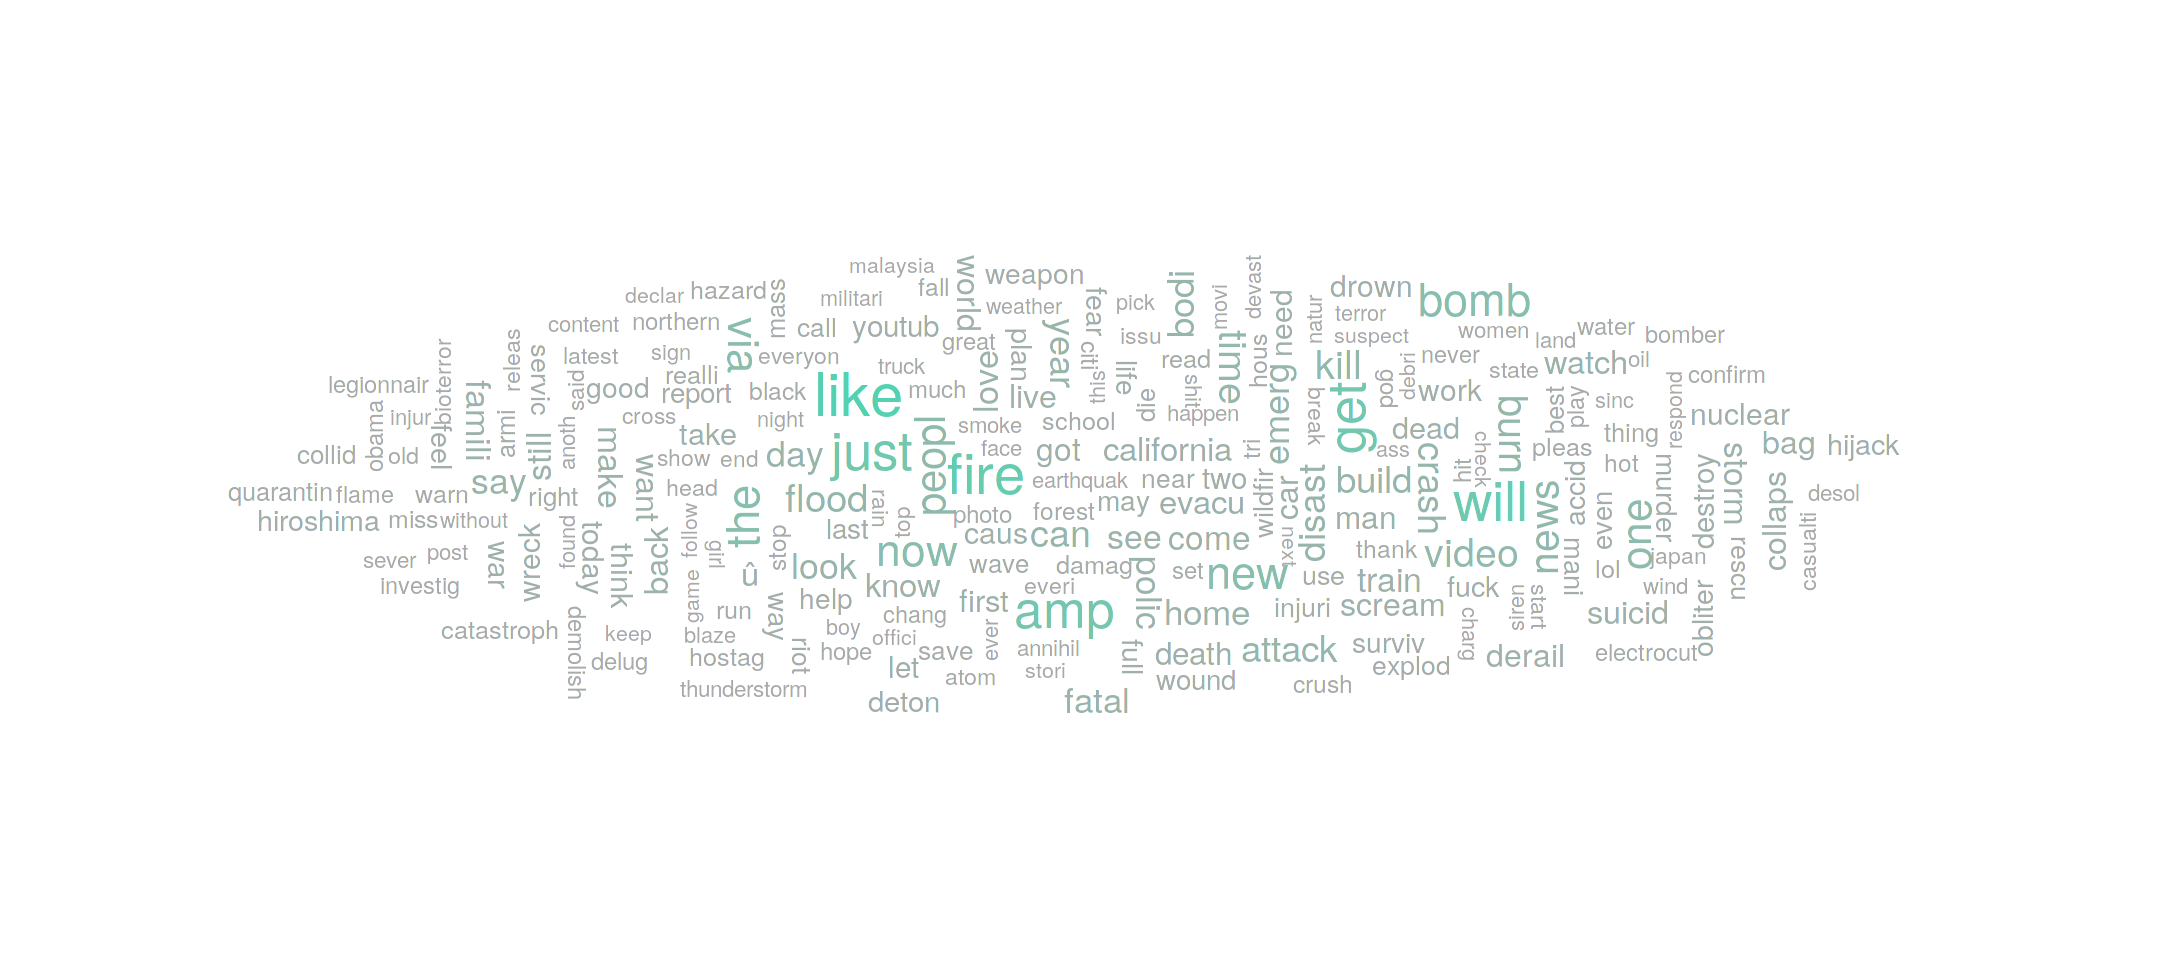

In [19]:
options(repr.plot.width = 18, repr.plot.height = 8) 
set.seed(5555)
freq$angle <- 45 * sample(-2:2, nrow(freq), replace = TRUE, prob = c(1, 0, 4, 0, 1))

ggplot(freq, aes(label = word, 
                    size = num, 
                    color = num, 
                    angle = angle)) +
  geom_text_wordcloud(shape = "circle", 
                      rm_outside = TRUE,
                      area_corr = F,
                      rstep = .01,
                      max_grid_size = 256,
                      grid_size = 7,
                      grid_margin = .4
  ) +
  scale_size_area(max_size = 12.5) +
  theme_minimal() +
  scale_color_gradient(low = "darkgrey", high = "#53d1b1")

<font size="+2" color="grey"><b>3. Deep Learning </b></font><br><a id="3"></a>
<a href="#top" class="btn-xs btn-default" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover" data-toggle="tooltip" title="Go back to the table of contents">Go back to the TOP</a>

Now we prepare the data for the application with tensorflow with keras. First the training data set is divided into a test and a learning data set by converting the list into a dataframe. We do not use the term document matrix but the corpus, because we want to work with word embeddings. More about word embeddings later.

Stop words, removement of numbers or punctation, and stemming reduce information, therefore they are not used in the following cleanUp function for text classification.

In [20]:
cleanUp <- function(CORPUS){
    CORPUS <- tm_map(CORPUS, content_transformer(tolower))
    CORPUS <- tm_map(CORPUS, content_transformer(function(x){mgsub(x, pattern = emojis, replacement = "")}))
    CORPUS <- tm_map(CORPUS, content_transformer(function(x){replace_contraction(x, contraction = contra)}))
    CORPUS <- tm_map(CORPUS, content_transformer(function(x){gsub("\\S*http+\\S*", "", x)}))
    CORPUS <- tm_map(CORPUS, stripWhitespace)
}

In [21]:
corpTRAIN <- Corpus(VectorSource(TRAIN$text)) %>% cleanUp()
corpTEST <- Corpus(VectorSource(TEST$text)) %>% cleanUp()

In [22]:
text <- unlist(corpTRAIN)
textTest <- unlist(corpTEST)

text <- as.data.frame(text)
textTest <- as.data.frame(textTest)

text <- text[1:(nrow(text)-1), ]
text <- as.data.frame(text)
tail(text)

textTest <- textTest[1:(nrow(textTest)-1), ]
textTest <- as.data.frame(textTest)
tail(textTest)

val <- data.frame(TRAIN$target, text$text)
colnames(val) <- c("target", "text")
head(val)

,text
,<fct>
7608,#stormchase violent record breaking ef-5 el reno oklahoma tornado nearly runs over ... -
7609,Two giant cranes holding a bridge collapse into nearby homes
7610,@aria_ahrary @thetawniest the out of control wild fires in california even in the northern part of the state. very troubling.
7611,M1.94 [01:04 utc]?5km s of volcano hawaii.
7612,Police investigating after an e-bike collided with a car in little portugal. e-bike rider suffered serious non-life threatening injuries.
7613,The latest: more homes razed by northern california wildfire - abc news


,textTest
,<fct>
3258,The death toll in a #is-suicide car bombing on a #ypg position in the village of rajman in the eastern province of hasaka has risen to 9
3259,Earthquake safety los angeles ûò safety fasteners xrwn
3260,Storm in ri worse than last hurricane. my city&amp;3others hardest hit. my yard looks like it was bombed. around 20000k still without power
3261,Green line derailment in chicago
3262,Meg issues hazardous weather outlook (hwo)
3263,#cityofcalgary has activated its municipal emergency plan. #yycstorm


,target,text
,<int>,<fct>
1,1,Our deeds are the reason of this #earthquake may allah forgive us all
2,1,Forest fire near la ronge sask. canada
3,1,All residents asked to 'shelter in place' are being notified by officers. no other evacuation or shelter in place orders are expected
4,1,"13,000 people receive #wildfires evacuation orders in california"
5,1,Just got sent this photo from ruby #alaska as smoke from #wildfires pours into a school
6,1,#rockyfire update => california hwy. 20 closed in both directions due to lake county fire - #cafire #wildfires


Train test partition:

In [23]:
ttPart <- .7
set.seed(123)
u <- runif(n = nrow(val), min = 0, max = 1)

tr_val <- val[u <= ttPart,]
te_val <- val[u > ttPart,]

In [24]:
head(tr_val); head(te_val)

,target,text
,<int>,<fct>
1,1,Our deeds are the reason of this #earthquake may allah forgive us all
3,1,All residents asked to 'shelter in place' are being notified by officers. no other evacuation or shelter in place orders are expected
6,1,#rockyfire update => california hwy. 20 closed in both directions due to lake county fire - #cafire #wildfires
7,1,"#flood #disaster heavy rain causes flash flooding of streets in manitou, colorado springs areas"
9,1,There is an emergency evacuation happening now in the building across the street
10,1,I am afraid that the tornado is coming to our area...


,target,text
,<int>,<fct>
2,1,Forest fire near la ronge sask. canada
4,1,"13,000 people receive #wildfires evacuation orders in california"
5,1,Just got sent this photo from ruby #alaska as smoke from #wildfires pours into a school
8,1,I am on top of the hill and i can see a fire in the woods...
11,1,Three people died from the heat wave so far
16,0,What is up man?


Dimensions:

In [25]:
dim(tr_val); dim(te_val)

[1] 5355    2

[1] 2258    2

<font size="+1" color="grey"><b>3.1 Tokenizer </b></font><br><a id="3.1"></a>
<a href="#top" class="btn-xs btn-default" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover" data-toggle="tooltip" title="Go back to the table of contents">Go back to the TOP</a>

A tokenizer is a procedure in which a unique value is assigned to each word. A maximum number of words is defined so as not to have too many categories. It is very important that the tokenizer is used for both training and test data sets. If a separate tokenizer were created for each record, different words would be assigned to different categories.

First step is to define the vocabulary size.

In [26]:
voc_size <- tr_val$text %>%
                as.character() %>%
                    paste(., collapse = " ") %>%
                        strsplit(., split = " ") %>%
                            unlist() %>%
                                factor() %>%
                                    unique() %>%
                                        length()

In [27]:
cat("Vocabulary size is:", voc_size)

Vocabulary size is: 19368

In [28]:
#GloVe <- fread("../input/glove-global-vectors-for-word-representation/glove.6B.50d.txt", quote = "")
#GloVe <- GloVe$V1
#voc_size <- length(GloVe)

In [29]:
tokenizer <- text_tokenizer(num_words = voc_size)

In [30]:
tokenizer %>%  fit_text_tokenizer(tr_val$text)

In [31]:
tokenizer$word_index %>% head(., n=6)

$the
[1] 1

$a
[1] 2

$`in`
[1] 3

$to
[1] 4

$of
[1] 5

$i
[1] 6

In [32]:
text_seqs_val_tr <- texts_to_sequences(tokenizer, tr_val$text)
text_seqs_val_te <- texts_to_sequences(tokenizer, te_val$text)
head(text_seqs_val_tr); head(text_seqs_val_te)

[[1]]
 [1]  114 3569   17    1  844    5   20  248  135 1474 3570   72   39

[[2]]
 [1]   39 2197 2198    4 5380    3 5381   17  127 5382   19 1475   41  388  249
[16]   55 1871    3  646 1340   17 1122

[[3]]
 [1] 2732  450   83 1222  680  753    3  716 5383  507    4 1223  348   56 5384
[16] 1341

[[4]]
 [1]  205   73  909  273 1342  754  237    5 2199    3 5385  845 2733 1654

[[5]]
 [1]  65   8  40  69 249 968  52   3   1 582 969   1 788

[[6]]
 [1]    6   26 1872   15    1  416    8  282    4  114  229

[[1]]
[1]  181   56  265  899 1553

[[2]]
[1]   995 12342    58  6366  1341   249  1340     3    83

[[3]]
 [1]   30   97 1302   20  331   22 2595   34  373   22 1341   70    2  177

[[4]]
 [1]    6   26   11  263    5    1 3100    7    6   71  123    2   56    3    1

[[5]]
[1] 740  58 545  22   1 329 641  35 558

[[6]]
[1] 50  8 31 90

Each tweed has a different length. That's why we expand all tweeds with a pad to a unique size. The padding fills the remaining columns with zeros (post-padding). Normally, the maximum size is 140, but due to the clean-ups we reduce the number of words per tweet to 120. The iput shape represents the number of features in the data set.

In [33]:
inputShape = 120

In [34]:
x_train <- text_seqs_val_tr %>% pad_sequences(maxlen = inputShape, padding = "post")
x_test <- text_seqs_val_te %>% pad_sequences(maxlen = inputShape, padding = "post")
dim(x_train); dim(x_test)
head(x_train); head(x_test)

[1] 5355  120

[1] 2258  120

114,3569,17,1,844,5,20,248,135,1474,⋯,0,0,0,0,0,0,0,0,0,0
39,2197,2198,4,5380,3,5381,17,127,5382,⋯,0,0,0,0,0,0,0,0,0,0
2732,450,83,1222,680,753,3,716,5383,507,⋯,0,0,0,0,0,0,0,0,0,0
205,73,909,273,1342,754,237,5,2199,3,⋯,0,0,0,0,0,0,0,0,0,0
65,8,40,69,249,968,52,3,1,582,⋯,0,0,0,0,0,0,0,0,0,0
6,26,1872,15,1,416,8,282,4,114,⋯,0,0,0,0,0,0,0,0,0,0


181,56,265,899,1553,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
995,12342,58,6366,1341,249,1340,3,83,0,⋯,0,0,0,0,0,0,0,0,0,0
30,97,1302,20,331,22,2595,34,373,22,⋯,0,0,0,0,0,0,0,0,0,0
6,26,11,263,5,1,3100,7,6,71,⋯,0,0,0,0,0,0,0,0,0,0
740,58,545,22,1,329,641,35,558,0,⋯,0,0,0,0,0,0,0,0,0,0
50,8,31,90,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [35]:
y_train <- tr_val$target
length(y_train)

[1] 5355

> Now let's see if the train- test split has a comparable data structure at all. But how should this work for natural language? The answer to this is called autoencoder.

<font size="+1" color="grey"><b>3.2 Auto Encoder </b></font><br><a id="3.2"></a>
<a href="#top" class="btn-xs btn-default" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover" data-toggle="tooltip" title="Go back to the table of contents">Go back to the TOP</a>

An autoencoder consists of an encoder that first reduces the dimensions. Then the representation is restored by the so-called decoder. This method is used for dimension reduction (like here) or for the creation of artificial representations.

![https://blog.keras.io/img/ae/autoencoder_schema.jpg](https://blog.keras.io/img/ae/autoencoder_schema.jpg)

If we manage to visualize the bottleneck, we can simply represent the compressed representations in a visualizable dimensionality and color them according to the target variable.

In [36]:
batch_size = 128
eps = 45
latent_size = 3
clip = 3
leRa = .0025
dec = .00001

Encoder and Decoder

In [37]:
ENCODER_in <- layer_input(shape = c(inputShape))
ENCODER_out = ENCODER_in %>%
  layer_embedding(input_dim = voc_size, 
                  output_dim = 30) %>%
  layer_dropout(.2) %>%
  layer_global_max_pooling_1d() %>%
  layer_batch_normalization() %>%
  layer_dense(units=120) %>% 
  layer_activation_leaky_relu() %>% 
  layer_dense(units=60) %>% 
  layer_activation_leaky_relu() %>% 
  layer_dense(units=latent_size) %>% 
  layer_activation_leaky_relu()
ENCODER = keras_model(ENCODER_in, ENCODER_out)
summary(ENCODER)

DECODER_in = layer_input(shape = latent_size)
DECODER_out = DECODER_in %>% 
  layer_batch_normalization() %>%
  layer_dense(units=60) %>% 
  layer_activation_leaky_relu() %>% 
  layer_dense(units=120) %>% 
  layer_activation_leaky_relu() %>% 
  layer_dense(units = inputShape, activation = "relu") # Because output must be >= 0
DECODER = keras_model(DECODER_in, DECODER_out)
summary(DECODER)

Model: "model"
________________________________________________________________________________
Layer (type)                        Output Shape                    Param #     
input_1 (InputLayer)                [(None, 120)]                   0           
________________________________________________________________________________
embedding (Embedding)               (None, 120, 30)                 581040      
________________________________________________________________________________
dropout (Dropout)                   (None, 120, 30)                 0           
________________________________________________________________________________
global_max_pooling1d (GlobalMaxPool (None, 30)                      0           
________________________________________________________________________________
batch_normalization (BatchNormaliza (None, 30)                      120         
________________________________________________________________________________
dense (Dense)

In [38]:
AEN_in = layer_input(shape = inputShape)
AEN_out = AEN_in %>% 
  ENCODER() %>% 
  DECODER()
   
AEN = keras_model(AEN_in, AEN_out)
summary(AEN)

Model: "model_2"
________________________________________________________________________________
Layer (type)                        Output Shape                    Param #     
input_3 (InputLayer)                [(None, 120)]                   0           
________________________________________________________________________________
model (Model)                       (None, 3)                       592323      
________________________________________________________________________________
model_1 (Model)                     (None, 120)                     22092       
Total params: 614,415
Trainable params: 614,349
Non-trainable params: 66
________________________________________________________________________________


Custom Loss

In [39]:
rmse <- function(y_pred, y_true){
  y_pred = k_cast(y_pred, dtype="float32")
  y_true = k_cast(y_true, dtype="float32")
  rmse = k_sqrt(k_mean(k_square(y_pred - y_true), axis=-1)) 
  return(rmse)
}

In [40]:
AEN %>% keras::compile(
  loss = rmse,
  optimizer = optimizer_adamax(beta_2 = .95, lr = leRa, decay = dec),
  metrics = c('accuracy')
)

In [41]:
stop <- callback_early_stopping(monitor = 'accuracy', patience = 10)

In [42]:
set.seed(123)

hist <- AEN %>%
  fit(
    x_train,
    x_train,
    batch_size = batch_size,
    epochs = eps,
    callbacks = c(stop)
  )

In [43]:
encoded = ENCODER %>% 
    predict(x_train)

In [44]:
decoded = DECODER %>% 
    predict(encoded) %>% 
        as.data.frame()

head(decoded)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,⋯,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1733.3578,1416.1564,1300.8260,1209.9598,1159.838,1146.2823,1197.602,1274.7852,1252.4525,1197.1095,⋯,0,0,0,0,0,0,0,0,0,0
2,2381.3994,1936.4673,1773.7469,1650.4130,1580.689,1561.4728,1632.329,1735.1630,1704.9561,1629.6641,⋯,0,0,0,0,0,0,0,0,0,0
3,2077.1284,1617.9021,1470.8829,1359.1373,1300.332,1278.6455,1337.451,1419.0687,1394.3162,1324.2715,⋯,0,0,0,0,0,0,0,0,0,0
4,1947.4397,1373.1627,1214.5707,1110.9911,1057.858,1027.4747,1077.071,1129.8843,1110.1537,1039.7010,⋯,0,0,0,0,0,0,0,0,0,0
5,1556.6544,1256.2577,1152.3588,1069.2628,1024.875,1011.5678,1056.956,1125.0347,1105.2349,1054.2776,⋯,0,0,0,0,0,0,0,0,0,0
6,915.9062,724.2961,665.0824,613.4865,588.584,579.6143,605.204,645.4088,633.7921,601.8239,⋯,0,0,0,0,0,0,0,0,0,0


In [45]:
encodedTest = ENCODER %>% 
    predict(x_test) %>% 
        as.data.frame()
encodedTest$split <- "validation"

In [46]:
encoded <- encoded %>% as.data.frame()
encoded$split <- "train"

In [47]:
encoded <- rbind(encoded, encodedTest)

The two-color split shows the training and validation datasets. Both are created from the training dataset.

In [48]:
col = c("#53d1b1", "grey")
Plot3D <- plot_ly(encoded, 
                  x=~V1, 
                  y=~V2, 
                  z=~V3, 
                  type="scatter3d", 
                  mode="markers", 
                  opacity = 1, 
                  color = ~split,
                  colors = col,
                  hoverinfo = 'text',
                  text = ~paste('V1:', V1, '<br>V2:', V2 ,"$", "<br>V3:", V3),
                  marker = list(size=6, 
                                symbol = "circle", 
                                line = list(color = 'grey', width = .01))
                  ) %>% 

layout(title = "Compressed Representation")

path <-"charts/Plot3D.html"
saveWidget(Plot3D, file.path(normalizePath(dirname(path)),basename(path)))
display_html('<iframe src="charts/Plot3D.html" align="center" width="100%" height="600" frameBorder="0"></iframe>')

It is noticeable that the train- test split is not comparable in all areas. This is typical for language, because it usually represents very complex structures of sequences. However, the final prediction has a similar problem. Therefore, we leave it as it is.

*By the way, the kink is caused by the leakyRelu activation function.*

<font size="+1" color="grey"><b>3.3 Deep Learning Architecture </b></font><br><a id="3.3"></a>
<a href="#top" class="btn-xs btn-default" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover" data-toggle="tooltip" title="Go back to the table of contents">Go back to the TOP</a>

For NLP purpose, the architecture of neural nets is very specific. In this case, it consists of an initial embedding followed by a classification model.

Early stopping:

In [49]:
stop1 <- callback_early_stopping(monitor = 'val_loss', patience = 7)
stop2 <- callback_early_stopping(monitor = 'val_loss', patience = 4)
stop3 <- callback_early_stopping(monitor = 'val_loss', patience = 7)

Set batch size not too high:

In [50]:
batch_size = 32

Defining the input shape. This depends on the method. If we would use a hidden state, we would have to use batch_shape instead of shape. The shape is in this case the number of columns:

In [51]:
cat("No of columns =", inputShape)

No of columns = 120

In [52]:
INPUT1 <- layer_input(shape = c(inputShape))
INPUT2 <- layer_input(shape = c(inputShape))
INPUT3 <- layer_input(shape = c(inputShape))

Instead of one hot encoding, which often leads to high variance, we use word embeddings. The one-hot matrix is used as input to match the weightings of the hidden layers with the individual categories. Depending on how many hidden layers are used so many features are created by the embedding. An embedding is therefore a preliminary neural network for categorical feature encoding.

*  input_dim is the number of categories to encode
*  output_dim is the number of hidden layers (features) you want to obtain. The lower the output_dim, the more information is lost. However, this is accompanied by a reduction in complexity, which reduces the predictive variance.

The first model is a Long Short Term Memory (LSTM) to learn the words in a meaningful sequence. Since language is often very complex and not every sentence unfolds its meaning from left to right, a bidirectional LSTM is used. the following image shows how it works:

![](https://i.stack.imgur.com/aTDpS.png)

The second model is a Multi Layer Perceptron (MLP) if form of a ResNet:

![](https://pvsmt99345.i.lithium.com/t5/image/serverpage/image-id/42339i8BA3F2CCCEDE7458/image-size/large?v=1.0&px=999)

The third model is a 1D-CNN. A 1D-CNN rolls over the sentences. It is capable of learning successive structures. It is mainly used in time series analysis.

![](https://cezannec.github.io/assets/cnn_text/conv_1D_time.gif)

In [53]:
OUTPUT1 <- INPUT1 %>%
        layer_embedding(input_dim = voc_size, 
                        output_dim = 6) %>%
        layer_dropout(.3) %>%
        bidirectional(layer_lstm(units = 16, 
                                 return_sequences = TRUE, 
                                 recurrent_dropout = .4,
                                 activation = "selu",
                                 kernel_initializer='lecun_normal')) %>%
        bidirectional(layer_lstm(units = 10, 
                                 return_sequences = FALSE, 
                                 recurrent_dropout = .35,
                                 activation = "elu")) %>%

        layer_dense(units = 1, activation = "sigmoid")

OUTPUT2.0 <- INPUT2 %>%
        layer_embedding(input_dim = voc_size, 
                        output_dim = 10) %>%
        layer_dropout(.4) %>%

        layer_global_max_pooling_1d() 

OUTPUT2.1 <- OUTPUT2.0 %>%
        layer_dense(units = 16) %>%
        layer_activation_leaky_relu() %>%
        layer_dropout(.4) %>%
        layer_batch_normalization() 

OUTPUT2.2 <- OUTPUT2.1 %>%
        layer_dense(units = 16) %>%
        layer_activation_leaky_relu() %>%
        layer_dropout(.4) %>%
        layer_batch_normalization() 

OUTPUT2 <- layer_average(list(OUTPUT2.1, OUTPUT2.2)) %>%

        layer_dense(units = 10) %>%
        layer_activation_leaky_relu() %>% 
        layer_dropout(.3) %>%
        layer_batch_normalization() %>%

        layer_dense(units = 1, activation = "sigmoid")

OUTPUT3 <- INPUT3 %>%
        layer_embedding(input_dim = voc_size, 
                        output_dim = 10) %>%
        layer_dropout(.35) %>%

        layer_conv_1d(filters = 8, 
                      kernel_size = 4, 
                      strides = 1, 
                      padding = "same") %>%
        layer_activation_leaky_relu() %>% 
        layer_batch_normalization() %>%
        layer_dropout(.35) %>%

        layer_conv_1d(filters = 16, 
                      kernel_size = 3, 
                      strides = 1, 
                      padding = "same") %>%
        layer_activation_leaky_relu() %>% 
        layer_batch_normalization() %>%
        layer_dropout(.35) %>%

        layer_conv_1d(filters = 24, 
                      kernel_size = 2, 
                      strides = 1, 
                      padding = "same") %>%
        layer_batch_normalization() %>%
        layer_activation_leaky_relu() %>% 
        layer_dropout(.35) %>%

        layer_flatten() %>%

        layer_dense(units = 1, activation = "sigmoid")

To obtain a trainable model one has to connect the input with the output of the model:

In [54]:
model1 <- keras_model(list(INPUT1), OUTPUT1)
model2 <- keras_model(list(INPUT2), OUTPUT2)
model3 <- keras_model(list(INPUT3), OUTPUT3)

Let´s take a look at the architecture:

In [55]:
summary(model1); summary(model2); summary(model3)

Model: "model_3"
________________________________________________________________________________
Layer (type)                        Output Shape                    Param #     
input_4 (InputLayer)                [(None, 120)]                   0           
________________________________________________________________________________
embedding_1 (Embedding)             (None, 120, 6)                  116208      
________________________________________________________________________________
dropout_1 (Dropout)                 (None, 120, 6)                  0           
________________________________________________________________________________
bidirectional (Bidirectional)       (None, 120, 32)                 2944        
________________________________________________________________________________
bidirectional_1 (Bidirectional)     (None, 20)                      3440        
________________________________________________________________________________
dense_6 (De

### Gradient tuning

A detailed explanation of the gradient decent tuning you will find <a href="https://www.kaggle.com/frankmollard/gradient-decent-tutorial"><span style="cursor:help"><font color="#53d1b1">here<font/></span></a>.

In [56]:
mom = .9
clip = 3
leRa = .0025
dec = .00001

Compiling the three models, all with adamax optimizer.

In [57]:
model1 %>% keras::compile(
  loss = tf$losses$BinaryCrossentropy(label_smoothing = 0),
  optimizer = optimizer_adamax(beta_2 = .95, lr = leRa, decay = dec),
  metrics = c('accuracy')
)

model2 %>% keras::compile(
  loss = tf$losses$BinaryCrossentropy(label_smoothing = 0),
  #optimizer_sgd(momentum = mom, nesterov = TRUE, clipvalue = clip, lr = leRa, decay = dec),
  optimizer = optimizer_adamax(beta_2 = .95, lr = leRa, decay = dec),
  metrics = c('accuracy')
)

model3 %>% keras::compile(
  loss = tf$losses$BinaryCrossentropy(label_smoothing = 0),
  optimizer = optimizer_adam(beta_2 = .95, lr = leRa + .0015, decay = dec),
  metrics = c('accuracy')
)

Setting the number of epochs:

In [58]:
eps = 45

<font size="+1" color="grey"><b>3.4 Cross Validation </b></font><br><a id="3.4"></a>
<a href="#top" class="btn-xs btn-default" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover" data-toggle="tooltip" title="Go back to the table of contents">Go back to the TOP</a>

Model training with early stopping:

In [59]:
set.seed(123)

hist1 <- model1 %>%
  fit(
    x_train,
    y_train,
    batch_size = batch_size,
    epochs = eps,
    validation_split = 0.3,
    callbacks = c(stop1)
  )

hist2 <- model2 %>%
  fit(
    x_train,
    y_train,
    batch_size = batch_size,
    epochs = eps,
    validation_split = 0.3,
    callbacks = c(stop2)
  )

hist3 <- model3 %>%
  fit(
    x_train,
    y_train,
    batch_size = batch_size,
    epochs = eps,
    validation_split = 0.3,
    callbacks = c(stop3)
  )

Let´s check the CV-performance.

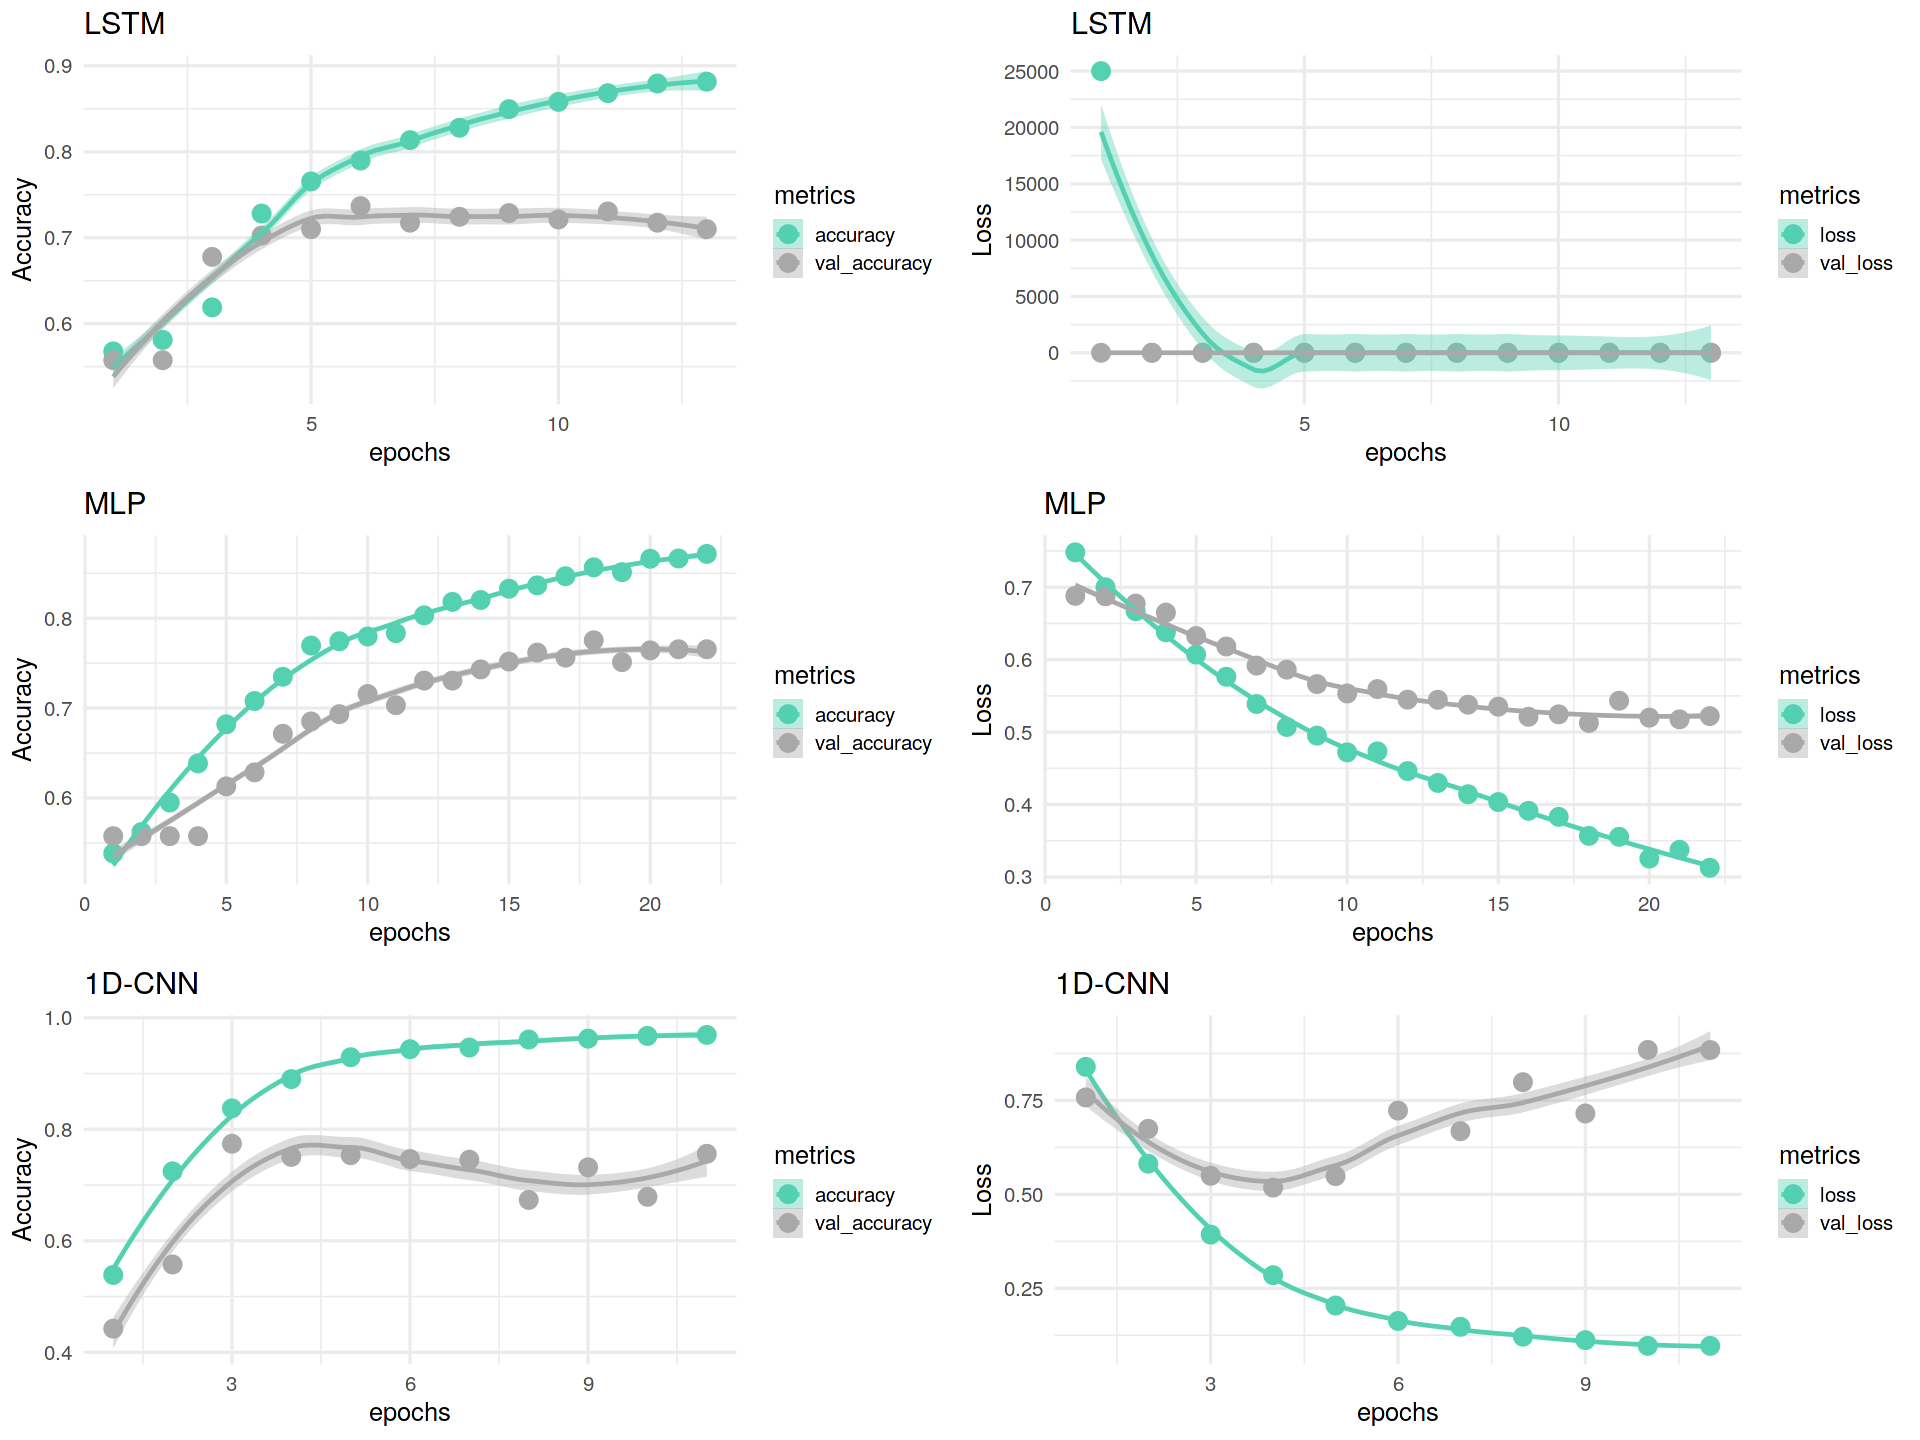

In [60]:
options(repr.plot.width = 16, repr.plot.height = 12)

cols <- c("#53d1b1", "darkgrey")

#hist1
met <- as.data.frame(unlist(hist1$metrics)) %>% rename(value = `unlist(hist1$metrics)`)
met$metrics <- gsub("\\d+", "", rownames(met))
met$epochs <- rep(1:(nrow(met)/4), times = 4)

met <- met %>% filter(metrics %in% c("accuracy", "val_accuracy"))

p11 <- ggplot(met, aes(x=epochs, y=value, color=metrics)) +
  geom_point(size=5, 
             shape=16) + 
  theme_minimal(base_size = 15) + 
  geom_smooth(method=loess, 
              aes(fill=metrics), 
              level = 0.5,
              formula = y ~ x
             ) +
  scale_color_manual(values = cols) + 
  scale_fill_manual(values = cols) + 
  ylab("Accuracy") + 
  ggtitle("LSTM")

met <- as.data.frame(unlist(hist1$metrics)) %>% rename(value = `unlist(hist1$metrics)`)
met$metrics <- gsub("\\d+", "", rownames(met))
met$epochs <- rep(1:(nrow(met)/4), times = 4)

met <- met %>% filter(metrics %in% c("loss", "val_loss"))

p12 <- ggplot(met, aes(x=epochs, y=value, color=metrics)) +
  geom_point(size=5, 
             shape=16) + 
  theme_minimal(base_size = 15) + 
  geom_smooth(method=loess, 
              aes(fill=metrics), 
              level = 0.5,
              formula = y ~ x
             ) +
  scale_color_manual(values = cols) + 
  scale_fill_manual(values = cols) + 
  ylab("Loss") + 
  ggtitle("LSTM")

#hist2

options(repr.plot.width = 16, repr.plot.height = 12)

met <- as.data.frame(unlist(hist2$metrics)) %>% rename(value = `unlist(hist2$metrics)`)
met$metrics <- gsub("\\d+", "", rownames(met))
met$epochs <- rep(1:(nrow(met)/4), times = 4)

met <- met %>% filter(metrics %in% c("accuracy", "val_accuracy"))

p21 <- ggplot(met, aes(x=epochs, y=value, color=metrics)) +
  geom_point(size=5, 
             shape=16) + 
  theme_minimal(base_size = 15) + 
  geom_smooth(method=loess, 
              aes(fill=metrics), 
              level = 0.5,
              formula = y ~ x
             ) +
  scale_color_manual(values = cols) + 
  scale_fill_manual(values = cols) + 
  ylab("Accuracy") + 
  ggtitle("MLP")

met <- as.data.frame(unlist(hist2$metrics)) %>% rename(value = `unlist(hist2$metrics)`)
met$metrics <- gsub("\\d+", "", rownames(met))
met$epochs <- rep(1:(nrow(met)/4), times = 4)

met <- met %>% filter(metrics %in% c("loss", "val_loss"))

p22 <- ggplot(met, aes(x=epochs, y=value, color=metrics)) +
  geom_point(size=5, 
             shape=16) + 
  theme_minimal(base_size = 15) + 
  geom_smooth(method=loess, 
              aes(fill=metrics), 
              level = 0.5,
              formula = y ~ x
             ) +
  scale_color_manual(values = cols) + 
  scale_fill_manual(values = cols) + 
  ylab("Loss") + 
  ggtitle("MLP")

#hist3

options(repr.plot.width = 16, repr.plot.height = 12)

met <- as.data.frame(unlist(hist3$metrics)) %>% rename(value = `unlist(hist3$metrics)`)
met$metrics <- gsub("\\d+", "", rownames(met))
met$epochs <- rep(1:(nrow(met)/4), times = 4)

met <- met %>% filter(metrics %in% c("accuracy", "val_accuracy"))

p31 <- ggplot(met, aes(x=epochs, y=value, color=metrics)) +
  geom_point(size=5, 
             shape=16) + 
  theme_minimal(base_size = 15) + 
  geom_smooth(method=loess, 
              aes(fill=metrics), 
              level = 0.5,
              formula = y ~ x
             ) +
  scale_color_manual(values = cols) + 
  scale_fill_manual(values = cols) + 
  ylab("Accuracy") + 
  ggtitle("1D-CNN")

met <- as.data.frame(unlist(hist3$metrics)) %>% rename(value = `unlist(hist3$metrics)`)
met$metrics <- gsub("\\d+", "", rownames(met))
met$epochs <- rep(1:(nrow(met)/4), times = 4)

met <- met %>% filter(metrics %in% c("loss", "val_loss"))

p32 <- ggplot(met, aes(x=epochs, y=value, color=metrics)) +
  geom_point(size=5, 
             shape=16) + 
  theme_minimal(base_size = 15) + 
  geom_smooth(method=loess, 
              aes(fill=metrics), 
              level = 0.5,
              formula = y ~ x
             ) +
  scale_color_manual(values = cols) + 
  scale_fill_manual(values = cols) + 
  ylab("Loss") + 
  ggtitle("1D-CNN")


grid.arrange(p11, p12, p21, p22, p31, p32, nrow = 3)

Let´s check the results:

In [61]:
results1 <- model1 %>% evaluate(x_test, te_val$target)
results2 <- model2 %>% evaluate(x_test, te_val$target)
results3 <- model3 %>% evaluate(x_test, te_val$target)
results1; results2; results3

$loss
[1] 0.6262664

$accuracy
[1] 0.7497786

$loss
[1] 0.5658789

$accuracy
[1] 0.7506643

$loss
[1] 1.013894

$accuracy
[1] 0.7555359

Let´s find the best weight to blend the models:

In [62]:
preds1 <- model1  %>% predict(x_test)
preds2 <- model2  %>% predict(x_test)
preds3 <- model3  %>% predict(x_test)

In [63]:
H=c(0:10*.1)
A = rep(NA, times = length(H))
AA = NULL
#h=.2
#b=.1
for(h in H) {
  B=c(0:(10-h*10)*.1)
  k = 1
      
  for(b in B){
        
    BagPred <-
          preds1 * h + 
          preds2 * b + 
          preds3 * (1 - b - h)
        
    A[k] <- sum(ifelse(round(BagPred) == te_val$target, 1, 0)) / nrow(te_val)
      
    k=k+1
  }

  A = as.data.frame(A)

  if(length(H)-nrow(A) != 0){
      NAs = as.data.frame(rep(NA, times = (length(H)-nrow(A))))
      colnames(NAs) = colnames(A)
      A = rbind(A, NAs)
  }
  AA = rbind(AA, t(A))

  A = rep(NA, times = length(H))

}

colnames(AA) <- seq(from = 0, to = 1, by = .1)
rownames(AA) <- seq(from = 0, to = 1, by = .1)

In [64]:
Maximum <- max(AA, na.rm = T)

M = NULL
z = which(AA == Maximum)
z = z[1]
row = ifelse(z%%11 == 0, z %/%11, z %/%11 + 1)
col = ifelse(z%%11 == 0, 11, z%%11)

cat("Maximum accuracy at", H[col], "= LSTM", H[row], "= MLP, and", (1-H[row]-H[col]), "= 1D-CNN")

Maximum accuracy at 0.4 = LSTM 0.4 = MLP, and 0.2 = 1D-CNN

In [65]:
AA <- melt(AA, na.rm = TRUE)
colnames(AA) = c("LSTM", "MLP", "accuracy")

p <- ggplot(data = AA, aes(x=MLP, y=LSTM, fill=accuracy)) + 
            geom_tile(color = "white") +
            scale_fill_gradient2(low = "#FFFFFF", high = "#4c6b6f", mid = "#53d1b1", 
            midpoint = .76, limit = c(.70, .80), space = "Lab", 
            name="accuracy\nmodel mix") +
            theme_minimal()+ 
            theme(axis.text.x = element_text(angle = 45, vjust = 1, 
                                             size = 12, hjust = 1),
                  axis.title = element_blank(),
                  panel.grid.major = element_blank(),
                  panel.background = element_blank()) +
            coord_fixed()

p <- ggplotly(p)

path <-"charts/Heat.html"
saveWidget(p, file.path(normalizePath(dirname(path)),basename(path)))
IRdisplay::display_html('<iframe src="charts/Heat.html" align="center" width="100%" height="500" frameBorder="0"></iframe>')

<font size="+1" color="grey"><b>3.5 Final Model </b></font><br><a id="3.4"></a>
<a href="#top" class="btn-xs btn-default" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover" data-toggle="tooltip" title="Go back to the table of contents">Go back to the TOP</a>

If the early stoping criterion has not worked, then you get a zero. Therefore, a condition is necessary:

In [66]:
eps1 = ifelse(stop1$stopped_epoch > 0, stop1$stopped_epoch, eps)
eps2 = ifelse(stop2$stopped_epoch > 0, stop2$stopped_epoch, eps)
eps3 = ifelse(stop3$stopped_epoch > 0, stop3$stopped_epoch, eps)

In [67]:
a = paste("The cross-validation for model1 stopped at ", eps1, " epochs. ", sep = "")
b = paste("The cross-validation for model2 stopped at ", eps2, " epochs.", sep = "")
c = paste("The cross-validation for model3 stopped at ", eps3, " epochs.", sep = "")

cat(a, b, c, sep = "\n")

The cross-validation for model1 stopped at 12 epochs. 
The cross-validation for model2 stopped at 21 epochs.
The cross-validation for model3 stopped at 10 epochs.


The tokenizer must always refer to either a pre-trained vector such as GloVe or Word2Vec or the training data! 

The eventual training data (val) is bigger than the validation data. So, we redefine the vocabulary size:

In [68]:
voc_size <- val$text %>%
                as.character() %>%
                    paste(., collapse = " ") %>%
                        strsplit(., split = " ") %>%
                            unlist() %>%
                                factor() %>%
                                    unique() %>%
                                        length()

In [69]:
cat("Vocabulary size is:", voc_size)

Vocabulary size is: 24806

In [70]:
tokenizer <- text_tokenizer(num_words = voc_size)
tokenizer %>%  fit_text_tokenizer(val$text)

Let´s check the tokenizer:

In [71]:
tokenizer$word_index %>% head()

$the
[1] 1

$a
[1] 2

$`in`
[1] 3

$to
[1] 4

$of
[1] 5

$i
[1] 6

Here we convert the text into a sequence again:

In [72]:
text_tr_seqs <- texts_to_sequences(tokenizer, val$text)
text_te_seqs <- texts_to_sequences(tokenizer, textTest$textTest)

head(text_tr_seqs); head(text_te_seqs)

[[1]]
 [1]  115 4564   17    1  852    5   20  258  134 1590 4565   73   40

[[2]]
[1]  185   44  224  785 6833 6834 1377

[[3]]
 [1]   40 1720 1591    4 6835    3 6836   17  133 6837   19 1721   39  432  251
[16]   58 2124    3  702 1378   17 1083

[[4]]
[1]  820 2872   60 4566 1471  251 1378    3   90

[[5]]
 [1]   34   94 1198   20  315   22 6838 2125   30  266   22 1471 6839   68    2
[16]  186

[[6]]
 [1] 2873  371   90 1472  786  853    3  655 6840  553    4 1137  391   44 4567
[16] 1471

[[1]]
[1]   34  895    2 1919  125   87

[[2]]
[1]  465   56  258    8 1178 2606  595 2283  240

[[3]]
 [1]   66    8    2  185   44   18  810 3514   17 5085  855    1  755    6  113
[16]  496   91   40

[[4]]
[1]  470 3878 7349 1471

[[5]]
[1]  213  781  468 2521    3  923    7 1183

[[6]]
[1]   37   17 4356   12    8   43  258

Padding:

In [73]:
x_train <- text_tr_seqs %>% pad_sequences(maxlen = inputShape, padding = "post") 
x_test <- text_te_seqs %>% pad_sequences(maxlen = inputShape, padding = "post")
dim(x_train); dim(x_test)
head(x_train); head(x_test)

[1] 7613  120

[1] 3263  120

115,4564,17,1,852,5,20,258,134,1590,⋯,0,0,0,0,0,0,0,0,0,0
185,44,224,785,6833,6834,1377,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
40,1720,1591,4,6835,3,6836,17,133,6837,⋯,0,0,0,0,0,0,0,0,0,0
820,2872,60,4566,1471,251,1378,3,90,0,⋯,0,0,0,0,0,0,0,0,0,0
34,94,1198,20,315,22,6838,2125,30,266,⋯,0,0,0,0,0,0,0,0,0,0
2873,371,90,1472,786,853,3,655,6840,553,⋯,0,0,0,0,0,0,0,0,0,0


34,895,2,1919,125,87,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
465,56,258,8,1178,2606,595,2283,240,0,⋯,0,0,0,0,0,0,0,0,0,0
66,8,2,185,44,18,810,3514,17,5085,⋯,0,0,0,0,0,0,0,0,0,0
470,3878,7349,1471,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
213,781,468,2521,3,923,7,1183,0,0,⋯,0,0,0,0,0,0,0,0,0,0
37,17,4356,12,8,43,258,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Target data:

In [74]:
y_train <- val$target
length(y_train)

[1] 7613

Redefine the architecture due to changing vocabulary size:

In [75]:
OUTPUT1 <- INPUT1 %>%
        layer_embedding(input_dim = voc_size, 
                        output_dim = 6) %>%
        layer_dropout(.3) %>%
        bidirectional(layer_lstm(units = 16, 
                                 return_sequences = TRUE, 
                                 recurrent_dropout = .4,
                                 activation = "selu",
                                 kernel_initializer='lecun_normal')) %>%
        bidirectional(layer_lstm(units = 10, 
                                 return_sequences = FALSE, 
                                 recurrent_dropout = .35,
                                 activation = "elu")) %>%

        layer_dense(units = 1, activation = "sigmoid")

OUTPUT2.0 <- INPUT2 %>%
        layer_embedding(input_dim = voc_size, 
                        output_dim = 10) %>%
        layer_dropout(.4) %>%

        layer_global_max_pooling_1d() 

OUTPUT2.1 <- OUTPUT2.0 %>%
        layer_dense(units = 16) %>%
        layer_activation_leaky_relu() %>%
        layer_dropout(.4) %>%
        layer_batch_normalization() 

OUTPUT2.2 <- OUTPUT2.1 %>%
        layer_dense(units = 16) %>%
        layer_activation_leaky_relu() %>%
        layer_dropout(.4) %>%
        layer_batch_normalization() 

OUTPUT2 <- layer_average(list(OUTPUT2.1, OUTPUT2.2)) %>%

        layer_dense(units = 10) %>%
        layer_activation_leaky_relu() %>% 
        layer_dropout(.3) %>%
        layer_batch_normalization() %>%

        layer_dense(units = 1, activation = "sigmoid")

OUTPUT3 <- INPUT3 %>%
        layer_embedding(input_dim = voc_size, 
                        output_dim = 10) %>%
        layer_dropout(.35) %>%

        layer_conv_1d(filters = 10, 
                      kernel_size = 4, 
                      strides = 1, 
                      padding = "same") %>%
        layer_activation_leaky_relu() %>% 
        layer_batch_normalization() %>%
        layer_dropout(.35) %>%

        layer_conv_1d(filters = 15, 
                      kernel_size = 3, 
                      strides = 1, 
                      padding = "same") %>%
        layer_activation_leaky_relu() %>% 
        layer_batch_normalization() %>%
        layer_dropout(.35) %>%

        layer_conv_1d(filters = 20, 
                      kernel_size = 2, 
                      strides = 1, 
                      padding = "same") %>%
        layer_batch_normalization() %>%
        layer_activation_leaky_relu() %>% 
        layer_dropout(.35) %>%

        layer_flatten() %>%

        layer_dense(units = 1, activation = "sigmoid")


model_final1 <- keras_model(list(INPUT1), OUTPUT1)
model_final2 <- keras_model(list(INPUT2), OUTPUT2)
model_final3 <- keras_model(list(INPUT3), OUTPUT3)


model_final1 %>% compile(
  loss = tf$losses$BinaryCrossentropy(label_smoothing = 0),
  optimizer = optimizer_adamax(beta_2 = .95, lr = leRa, decay = dec),
  metrics = c('accuracy')
)

model_final2 %>% compile(
  loss = tf$losses$BinaryCrossentropy(label_smoothing = 0),
  #optimizer_sgd(momentum = mom, nesterov = TRUE, clipvalue = clip, lr = leRa, decay = dec),
  optimizer = optimizer_adamax(beta_2 = .95, lr = leRa, decay = dec),
  metrics = c('accuracy')
)

model_final3 %>% compile(
  loss = tf$losses$BinaryCrossentropy(label_smoothing = 0),
  optimizer = optimizer_adam(beta_2 = .95, lr = leRa + .0015, decay = dec),
  metrics = c('accuracy')
)

Train models with appropriate epochs:

In [76]:
hist1 <- model_final1 %>%
  fit(
    x_train,
    y_train,
    batch_size = batch_size,
    epochs = eps1
  )

hist2 <- model_final2 %>%
  fit(
    x_train,
    y_train,
    batch_size = batch_size,
    epochs = eps2
  )

hist3 <- model_final3 %>%
  fit(
    x_train,
    y_train,
    batch_size = batch_size,
    epochs = eps3
  )

Prediction:

In [77]:
preds1 <- model_final1  %>% predict(x_test)
preds2 <- model_final2  %>% predict(x_test)
preds3 <- model_final3  %>% predict(x_test)

blend <- H[row] * preds1 + H[col] * preds2 + (1-H[row]-H[col]) * preds3
head(blend)

0.7993369
0.5652098
0.7732456
0.5860673
0.9954731
0.8061031


<font size="+2" color="grey"><b>4. Submission </b></font><br><a id="4"></a>
<a href="#top" class="btn-xs btn-default" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover" data-toggle="tooltip" title="Go back to the table of contents">Go back to the TOP</a>

Let´s have a look at the encoded layers again to get an idea of the position of predicted values.

In [78]:
encodedTest = ENCODER %>% 
    predict(x_test) %>% 
        as.data.frame()

library(dichromat)

colFun <- colorRampPalette(c("white", "#53d1b1"))
colGrad <- colFun(100)

predictions <- blend %>% as.data.frame()
encodedTest$prediction <- predictions$V1

Plot3D <- plot_ly(encodedTest, 
                  x=~V1, 
                  y=~V2, 
                  z=~V3, 
                  type="scatter3d", 
                  mode="markers", 
                  opacity = 1, 
                  color = ~prediction,
                  colors = colGrad,
                  hoverinfo = 'text',
                  text = ~paste('Prediction:', prediction),
                  marker = list(size=6, 
                                symbol = "circle", 
                                line = list(color = 'darkgrey', width = .01),
                                showscale = FALSE
                                )
                  ) %>% 

layout(title = "Compressed Representation Colored by Prediction")

path <-"charts/Plot3D2.html"
saveWidget(Plot3D, file.path(normalizePath(dirname(path)),basename(path)))
display_html('<iframe src="charts/Plot3D2.html" align="center" width="100%" height="600" frameBorder="0"></iframe>')

Reading in the sample submission file:

In [79]:
SamSub <- fread("../input/nlp-getting-started/sample_submission.csv")

Submit:

In [80]:
SamSub$target <- round(blend)
head(SamSub, n = 20)

fwrite(SamSub, "SampleSubmission.csv")

id,target
<int>,<dbl>
0,1
2,1
3,1
9,1
11,1
12,1
21,0
22,0
27,0


### <center>If you like the kernel, give it an upvote:</center>
<center><a href="#top" class="btn btn-default btn-lg active" role="button" aria-pressed="true" style="color:#53d1b1" data-toggle="popover">Go back to the TOP</a></center>